In [1]:
from scipy.io import netcdf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import datetime as dt
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import pandas as pd
import glob
import copy
import pickle
import matplotlib.path as mpath
from netCDF4 import Dataset
import xarray as xr


In [2]:
datasets = ["ERA5", "MERRA2", "JRA3Q"]

OUT_DIR_List = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q"
}
yearnameList = {
    "ERA5": "1979_2025",
    "MERRA2": "1980_2025",
    "JRA3Q": "1979_2025"
}
timerefFile = {
    "ERA5": "/scratch/bell/hu1029/Data/processed/ERA5_Z500_6hr_1979_2025_1dg.nc",
    "MERRA2": "/scratch/bell/hu1029/Data/processed/MERRA2_Z500_6hr_1980_2025_1dg.nc",
    "JRA3Q": "/scratch/bell/hu1029/Data/processed/JRA3Q_Z500_6hr_1979_2025_1dg.nc"
}
latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lat_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lat_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_LWA_lat_1979_2025_6hr.npy"
}
lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lon_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lon_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_LWA_lon_1979_2025_6hr.npy"
}
TRACK_latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lat_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lat_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_TRACK_lat_1979_2025_6hr.npy"
}
TRACK_lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lon_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lon_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_TRACK_lon_1979_2025_6hr.npy"
}

In [3]:
# %% 00 function preparation --------------------------------
regions = ["ATL", "NP", "SP"]
seasons = [ "ALL", "DJF", "JJA"]
seasonsmonths = [[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], [12, 1, 2], [6, 7, 8]]
blkTypes = ["Ridge", "Trough", "Dipole"]
cycTypes = ["AC", "CC"]

def Region_ERA(regionname): 
    if regionname == "ATL": 
        lat_min, lat_max, lon_min, lon_max = 45, 75, 300, 60
    elif regionname == "NP": 
        lat_min, lat_max, lon_min, lon_max = 40, 70, 130, 250
    elif regionname == "SP": 
        lat_min, lat_max, lon_min, lon_max = -75, -45, 180, 300
    return lat_min, lat_max, lon_min, lon_max

def PlotBoundary(regionname): 
    if regionname == "ATL": 
        lat_min, lat_max, lon_min, lon_max, loncenter = 30, 90, 250, 90, 350
    elif regionname == "NP": 
        lat_min, lat_max, lon_min, lon_max, loncenter = 30, 90, 80, 280, 180
    elif regionname == "SP": 
        lat_min, lat_max, lon_min, lon_max, loncenter = -90, -30, 130, 330, 230

    return lat_min, lat_max, lon_min, lon_max, loncenter

def findClosest(lati, latids):

    if isinstance(lati, (np.ndarray, list)):  # if lat is an array or list
        closest_indices = []
        for l in lati:  
            diff = np.abs(l - latids)
            closest_idx = np.argmin(diff) 
            closest_indices.append(closest_idx)
        return closest_indices
    else:
        # if lat is a single value
        diff = np.abs(lati - latids)
        return np.argmin(diff) 

In [6]:
dtname = "ERA5"
OUTDIR = OUT_DIR_List[dtname]
timereff = timerefFile[dtname]
latref = latrefFile[dtname]
lonref = lonrefFile[dtname]
yearname = yearnameList[dtname]

In [7]:
#%% 01 read the data - time management

### Time Management ###
start_year, end_year = map(int, yearname.split('_'))
Datestamp = pd.date_range(start=f"{start_year}-01-01", end=f"{end_year}-12-31")
Date0 = pd.DataFrame({'date': pd.to_datetime(Datestamp)})
Date = list(Date0['date'])
nday = len(Date)
Month = Date0['date'].dt.month
Year = Date0['date'].dt.year
Day = Date0['date'].dt.day
# get the DJF date indices
BAMDate = Date0
DJF_index = np.array(BAMDate[BAMDate['date'].dt.month.isin([12, 1, 2])].index)
print('DJF_index:', DJF_index, flush=True)
print(len(DJF_index), flush=True)
offsets = np.arange(-5, 1)  
DJF_index_preceding = np.unique(np.concatenate([DJF_index + offset for offset in offsets]))
print('DJF preceding index:', DJF_index_preceding, flush=True)

# lat and lon
lat = np.load(latref) # increasing order (-90~90)
lon = np.load(lonref)
lat1dg_mid = int(len(lat)/2) + 1 #91
Blklon = lon
tracklon = lon



DJF_index: [    0     1     2 ... 17164 17165 17166]
4242
DJF preceding index: [   -5    -4    -3 ... 17164 17165 17166]


In [8]:
type_idx = 0
ss = "ALL"
regions_S_B_freq = np.load(f'{OUTDIR}/{dtname}_{blkTypes[type_idx]}_{ss}_regions_S_B_freq.npy')
regions_S_LB_freq = np.load(f'{OUTDIR}/{dtname}_{blkTypes[type_idx]}_{ss}_regions_S_LB_freq.npy')
regions_S_freq_clima = np.load(f'{OUTDIR}/{dtname}_{blkTypes[type_idx]}_{ss}_regions_S_freq_clima.npy')


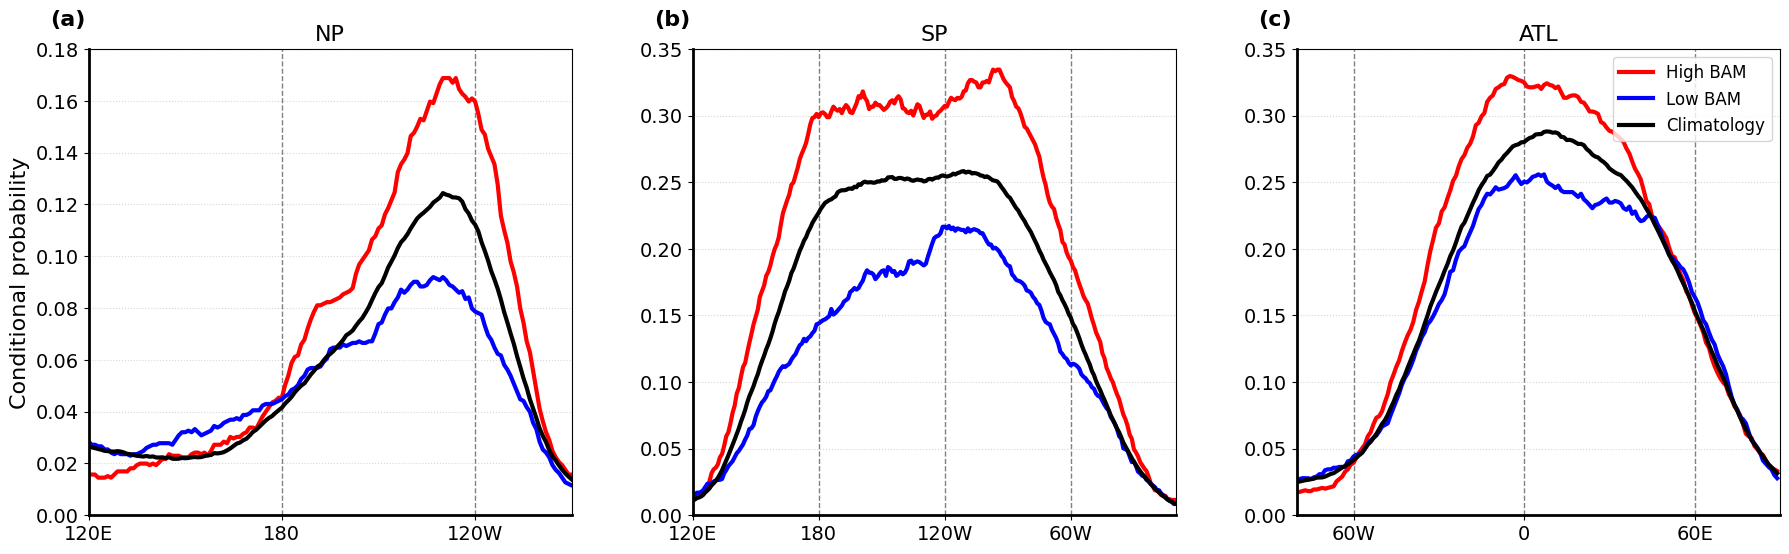

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import string

regions = ['NP', 'SP', 'ATL']
region_indices = [1, 2, 0]  # NP, SP, ATL order for plotting

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (ax, ridx, region) in enumerate(zip(axes, region_indices, regions)):

    # --- read data ---
    S_B_freq = regions_S_B_freq[ridx]
    S_LB_freq = regions_S_LB_freq[ridx]
    S_freq_clima = regions_S_freq_clima[ridx]

    # --- shift lon ---
    Blklon = np.concatenate((lon[90:], lon[0:90] + 360))

    S_B_freq = np.concatenate((S_B_freq[90:], S_B_freq[:90]))
    S_LB_freq = np.concatenate((S_LB_freq[90:], S_LB_freq[:90]))
    S_freq_clima = np.concatenate((S_freq_clima[90:], S_freq_clima[:90]))

    # --- plot ---
    ax.plot(Blklon, S_B_freq, color='red', linewidth=3, label='High BAM')
    ax.plot(Blklon, S_LB_freq, color='blue', linewidth=3, label='Low BAM')
    ax.plot(Blklon, S_freq_clima, color='black', linewidth=3, label='Climatology')

    # --- xticks for each region ---
    if region == 'ATL':
        ax.set_xticks([300, 360, 420])
        ax.set_xticklabels(['60W', '0', '60E'], fontsize=14)
        ax.set_xlim(280, 450)

    elif region == 'NP':
        ax.set_xticks([120, 180, 240, 300, 360, 420])
        ax.set_xticklabels(['120E', '180', '120W', '60W', '0', '60E'], fontsize=14)
        ax.set_xlim(120, 270)

    elif region == 'SP':
        ax.set_xticks([120, 180, 240, 300])
        ax.set_xticklabels(['120E', '180', '120W', '60W'], fontsize=14)
        ax.set_xlim(120, 350)

    # y-axis limits
    if region == 'NP':
        ax.set_ylim(0, 0.18)

    elif region == 'ATL':
        ax.set_ylim(0, 0.35)

    elif region == 'SP':
        ax.set_ylim(0, 0.35)

    # --- grid & style ---
    ax.grid(axis='x', linestyle='--', color='gray', linewidth=1)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    ax.tick_params(labelsize=14)

    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)

    # --- panel label (a)(b)(c) ---
    label = f'({string.ascii_lowercase[i]})'
    ax.text(-0.08, 1.05, label,
            transform=ax.transAxes,
            fontsize=16, fontweight='bold')

    # --- region title ---
    ax.set_title(region, fontsize=16)

# --- ylabel only once ---
axes[0].set_ylabel('Conditional probability', fontsize=16)

# --- legend（only one）---
axes[-1].legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.85, wspace=0.25)

plt.savefig(f'./FINAL_figures/{dtname}_fig3_allregions_Type{type_idx+1}_{ss}.png', dpi=300)
plt.show()

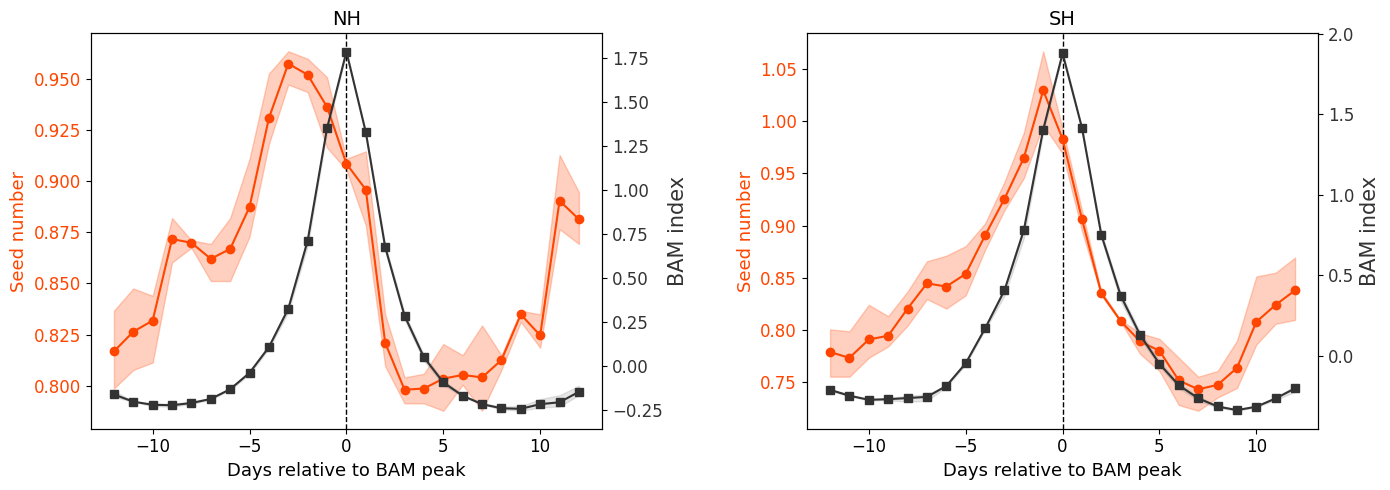

In [10]:
datasets = ["ERA5", "MERRA2", "JRA3Q"]

days = np.arange(-12, 13)

# --- collect all datasets ---
seed_NH_list, seed_SH_list = [], []
bam_NH_list, bam_SH_list = [], []

for dtname in datasets:
    OUTDIR = OUT_DIR_List[dtname]

    seed_NH_list.append(np.load(f"{OUTDIR}/{dtname}_BAMseedNumber_composite_NH_mean.npy"))
    seed_SH_list.append(np.load(f"{OUTDIR}/{dtname}_BAMseedNumber_composite_SH_mean.npy"))

    bam_NH_list.append(np.load(f"{OUTDIR}/{dtname}_BAMindex_composite_NH_mean.npy"))
    bam_SH_list.append(np.load(f"{OUTDIR}/{dtname}_BAMindex_composite_SH_mean.npy"))

# --- convert to arrays ---
seed_NH_arr = np.stack(seed_NH_list, axis=0)
seed_SH_arr = np.stack(seed_SH_list, axis=0)
bam_NH_arr  = np.stack(bam_NH_list, axis=0)
bam_SH_arr  = np.stack(bam_SH_list, axis=0)

# --- mean ---
seed_NH_mean = np.mean(seed_NH_arr, axis=0)
seed_SH_mean = np.mean(seed_SH_arr, axis=0)
bam_NH_mean  = np.mean(bam_NH_arr, axis=0)
bam_SH_mean  = np.mean(bam_SH_arr, axis=0)

# --- range (for shading) ---
seed_NH_min, seed_NH_max = np.min(seed_NH_arr, axis=0), np.max(seed_NH_arr, axis=0)
seed_SH_min, seed_SH_max = np.min(seed_SH_arr, axis=0), np.max(seed_SH_arr, axis=0)
bam_NH_min, bam_NH_max   = np.min(bam_NH_arr, axis=0),  np.max(bam_NH_arr, axis=0)
bam_SH_min, bam_SH_max   = np.min(bam_SH_arr, axis=0),  np.max(bam_SH_arr, axis=0)

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for i, (ax, hemi) in enumerate(zip(axes, ['NH', 'SH'])):

    # select data
    if hemi == 'NH':
        seed_mean, seed_min, seed_max = seed_NH_mean, seed_NH_min, seed_NH_max
        bam_mean, bam_min, bam_max = bam_NH_mean, bam_NH_min, bam_NH_max
    else:
        seed_mean, seed_min, seed_max = seed_SH_mean, seed_SH_min, seed_SH_max
        bam_mean, bam_min, bam_max = bam_SH_mean, bam_SH_min, bam_SH_max

    # --- left axis (seeding number) ---
    ax.plot(days, seed_mean, color='orangered', marker='o',
            label='Seed number', zorder=3)

    ax.fill_between(days, seed_min, seed_max,
                    color='orangered', alpha=0.25, zorder=2)

    ax.set_xlabel('Days relative to BAM peak', fontsize=13)
    ax.set_ylabel('Seed number', color='orangered', fontsize=13)
    ax.tick_params(axis='y', labelcolor='orangered', labelsize=12)
    ax.tick_params(axis='x', labelsize=12)

    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    # ax.grid(alpha=0.3)

    # --- right axis (BAM index) ---
    ax2 = ax.twinx()

    ax2.plot(days, bam_mean, color='0.2', marker='s',
             label='BAM index', zorder=2)

    ax2.fill_between(days, bam_min, bam_max,
                     color='gray', alpha=0.2, zorder=1)

    ax2.set_ylabel('BAM index', color='0.2', fontsize=15)
    ax2.tick_params(axis='y', labelcolor='0.2', labelsize=12)

    # --- title ---
    ax.set_title(hemi, fontsize=14)

# --- layout ---
plt.tight_layout()
plt.subplots_adjust(wspace=0.4)

plt.show()

### put into one figure

In [11]:
regions_S_B_freq_all = {}
regions_S_LB_freq_all = {}
regions_S_freq_clima_all = {}

type_idx = 0
ss = "ALL"

for dtname in datasets:
    OUTDIR = OUT_DIR_List[dtname]

    regions_S_B_freq_all[dtname] = np.load(
        f'{OUTDIR}/{dtname}_{blkTypes[type_idx]}_{ss}_regions_S_B_freq.npy'
    )
    regions_S_LB_freq_all[dtname] = np.load(
        f'{OUTDIR}/{dtname}_{blkTypes[type_idx]}_{ss}_regions_S_LB_freq.npy'
    )
    regions_S_freq_clima_all[dtname] = np.load(
        f'{OUTDIR}/{dtname}_{blkTypes[type_idx]}_{ss}_regions_S_freq_clima.npy'
    )

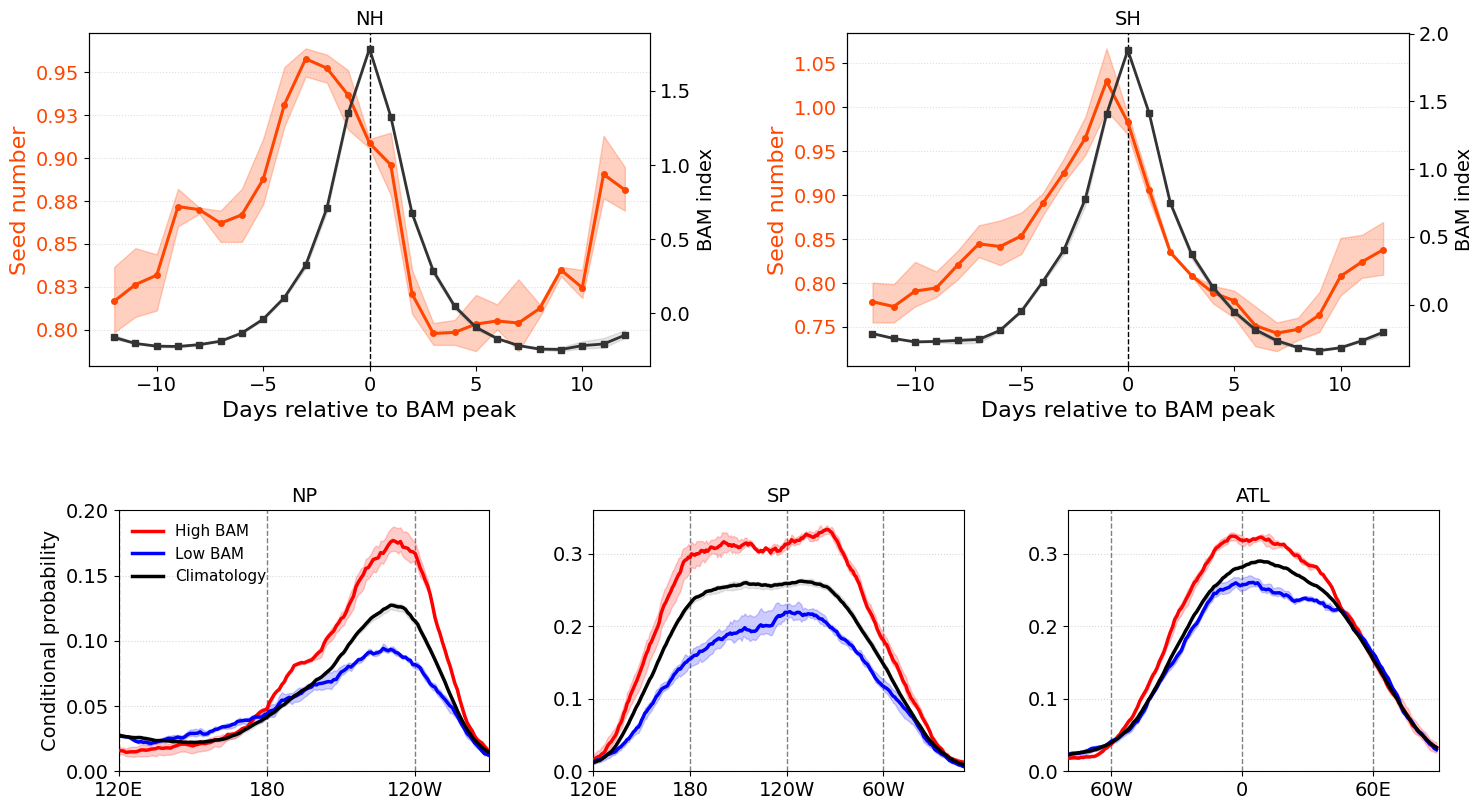

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import string

# -------------------------------
# Part 1: load 3-dataset means/ranges for top row
# -------------------------------
days = np.arange(-12, 13)

seed_NH_list, seed_SH_list = [], []
bam_NH_list, bam_SH_list = [], []

for dtname in datasets:
    OUTDIR = OUT_DIR_List[dtname]

    seed_NH_list.append(np.load(f"{OUTDIR}/{dtname}_BAMseedNumber_composite_NH_mean.npy"))
    seed_SH_list.append(np.load(f"{OUTDIR}/{dtname}_BAMseedNumber_composite_SH_mean.npy"))

    bam_NH_list.append(np.load(f"{OUTDIR}/{dtname}_BAMindex_composite_NH_mean.npy"))
    bam_SH_list.append(np.load(f"{OUTDIR}/{dtname}_BAMindex_composite_SH_mean.npy"))

seed_NH_arr = np.stack(seed_NH_list, axis=0)
seed_SH_arr = np.stack(seed_SH_list, axis=0)
bam_NH_arr  = np.stack(bam_NH_list, axis=0)
bam_SH_arr  = np.stack(bam_SH_list, axis=0)

seed_NH_mean = np.mean(seed_NH_arr, axis=0)
seed_SH_mean = np.mean(seed_SH_arr, axis=0)
bam_NH_mean  = np.mean(bam_NH_arr, axis=0)
bam_SH_mean  = np.mean(bam_SH_arr, axis=0)

seed_NH_min, seed_NH_max = np.min(seed_NH_arr, axis=0), np.max(seed_NH_arr, axis=0)
seed_SH_min, seed_SH_max = np.min(seed_SH_arr, axis=0), np.max(seed_SH_arr, axis=0)
bam_NH_min, bam_NH_max   = np.min(bam_NH_arr, axis=0), np.max(bam_NH_arr, axis=0)
bam_SH_min, bam_SH_max   = np.min(bam_SH_arr, axis=0), np.max(bam_SH_arr, axis=0)

# -------------------------------
# Part 2: make big figure layout
# -------------------------------
fig = plt.figure(figsize=(15, 9))

# first row: 2 columns
gs_top = fig.add_gridspec(
    nrows=1, ncols=2,
    left=0.08, right=0.96,
    top=0.95, bottom=0.58,
    wspace=0.35
)

ax_a = fig.add_subplot(gs_top[0, 0])   # NH
ax_b = fig.add_subplot(gs_top[0, 1])   # SH

# second row: 3 columns
gs_bot = fig.add_gridspec(
    nrows=1, ncols=3,
    left=0.1, right=0.98,
    top=0.42,
    bottom=0.13,
    wspace=0.28
)

ax_c = fig.add_subplot(gs_bot[0, 0])   # NP
ax_d = fig.add_subplot(gs_bot[0, 1])   # SP
ax_e = fig.add_subplot(gs_bot[0, 2])   # ATL

# -------------------------------
# Part 3: top row plotting
# -------------------------------
top_axes = [ax_a, ax_b]
top_hemis = ['NH', 'SH']

for i, (ax, hemi) in enumerate(zip(top_axes, top_hemis)):

    if hemi == 'NH':
        seed_mean, seed_min, seed_max = seed_NH_mean, seed_NH_min, seed_NH_max
        bam_mean, bam_min, bam_max = bam_NH_mean, bam_NH_min, bam_NH_max
    else:
        seed_mean, seed_min, seed_max = seed_SH_mean, seed_SH_min, seed_SH_max
        bam_mean, bam_min, bam_max = bam_SH_mean, bam_SH_min, bam_SH_max

    leftcol = 'orangered'

    # left y-axis: seed number
    ax.plot(
        days, seed_mean,
        color=leftcol, marker='o', markersize=4,
        linewidth=2.2, zorder=3
    )
    ax.fill_between(
        days, seed_min, seed_max,
        color=leftcol, alpha=0.25, zorder=2
    )

    ax.set_xlabel('Days relative to BAM peak', fontsize=16)
    ax.set_ylabel('Seed number', color=leftcol, fontsize=16)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelcolor=leftcol, labelsize=14)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(hemi, fontsize=14)
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    # right y-axis: BAM index
    ax2 = ax.twinx()
    ax2.plot(
        days, bam_mean,
        color='0.2', marker='s', markersize=4,
        linewidth=2.0, zorder=2
    )
    ax2.fill_between(
        days, bam_min, bam_max,
        color='gray', alpha=0.2, zorder=1
    )
    ax2.set_ylabel('BAM index', color='black', fontsize=14)
    ax2.tick_params(axis='y', labelcolor='black', labelsize=14)

# -------------------------------
# Part 4: bottom row plotting
# -------------------------------
regions = ['NP', 'SP', 'ATL']
region_indices = [1, 2, 0]   # NP, SP, ATL
bottom_axes = [ax_c, ax_d, ax_e]

def shift_lon_center270(arr):
    return np.concatenate((arr[90:], arr[:90]))

Blklon = np.concatenate((lon[90:], lon[:90] + 360))

for j, (ax, ridx, region) in enumerate(zip(bottom_axes, region_indices, regions)):

    # --- collect all datasets for this region ---
    S_B_list = []
    S_LB_list = []
    S_clim_list = []

    for dtname in datasets:
        S_B_list.append(regions_S_B_freq_all[dtname][ridx])
        S_LB_list.append(regions_S_LB_freq_all[dtname][ridx])
        S_clim_list.append(regions_S_freq_clima_all[dtname][ridx])

    # stack
    S_B_arr = np.stack(S_B_list, axis=0)
    S_LB_arr = np.stack(S_LB_list, axis=0)
    S_clim_arr = np.stack(S_clim_list, axis=0)

    # mean
    S_B_mean = np.mean(S_B_arr, axis=0)
    S_LB_mean = np.mean(S_LB_arr, axis=0)
    S_clim_mean = np.mean(S_clim_arr, axis=0)

    # range
    S_B_min, S_B_max = np.min(S_B_arr, axis=0), np.max(S_B_arr, axis=0)
    S_LB_min, S_LB_max = np.min(S_LB_arr, axis=0), np.max(S_LB_arr, axis=0)
    S_clim_min, S_clim_max = np.min(S_clim_arr, axis=0), np.max(S_clim_arr, axis=0)

    # shift longitude
    S_B_mean = shift_lon_center270(S_B_mean)
    S_LB_mean = shift_lon_center270(S_LB_mean)
    S_clim_mean = shift_lon_center270(S_clim_mean)

    S_B_min = shift_lon_center270(S_B_min)
    S_B_max = shift_lon_center270(S_B_max)
    S_LB_min = shift_lon_center270(S_LB_min)
    S_LB_max = shift_lon_center270(S_LB_max)
    S_clim_min = shift_lon_center270(S_clim_min)
    S_clim_max = shift_lon_center270(S_clim_max)

    # plot mean lines
    ax.plot(Blklon, S_B_mean, color='red', linewidth=2.5, label='High BAM', zorder=3)
    ax.plot(Blklon, S_LB_mean, color='blue', linewidth=2.5, label='Low BAM', zorder=3)
    ax.plot(Blklon, S_clim_mean, color='black', linewidth=2.5, label='Climatology', zorder=3)

    # shading = inter-dataset range
    ax.fill_between(Blklon, S_B_min, S_B_max, color='red', alpha=0.2, zorder=2)
    ax.fill_between(Blklon, S_LB_min, S_LB_max, color='blue', alpha=0.2, zorder=2)
    ax.fill_between(Blklon, S_clim_min, S_clim_max, color='gray', alpha=0.2, zorder=1)

    # axis settings
    if region == 'ATL':
        ax.set_xticks([300, 360, 420])
        ax.set_xticklabels(['60W', '0', '60E'], fontsize=14)
        ax.set_xlim(280, 450)
        ax.set_ylim(0, 0.36)

    elif region == 'NP':
        ax.set_xticks([120, 180, 240, 300, 360, 420])
        ax.set_xticklabels(['120E', '180', '120W', '60W', '0', '60E'], fontsize=14)
        ax.set_xlim(120, 270)
        ax.set_ylim(0, 0.20)

    elif region == 'SP':
        ax.set_xticks([120, 180, 240, 300])
        ax.set_xticklabels(['120E', '180', '120W', '60W'], fontsize=12)
        ax.set_xlim(120, 350)
        ax.set_ylim(0, 0.36)

    ax.grid(axis='x', linestyle='--', color='gray', linewidth=1)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.tick_params(labelsize=14)
    ax.set_title(region, fontsize=14)


bottom_axes[0].set_ylabel('Conditional probability', fontsize=14)
bottom_axes[0].legend(loc='upper left', fontsize=11, frameon=False)

# -------------------------------
# Save / show
# -------------------------------
plt.savefig(f'./FINAL_figures/Nature_Fig3.png', dpi=300, bbox_inches='tight')
plt.show()